# Demo 2 (extensão) — RNN e LSTM de Verdade

## Por que este notebook existe?

No `demo2_limite_do_contexto.ipynb` usamos uma **simulação** do esvanecimento de memória — uma fórmula `fator ** passos` que ilustra o comportamento sem implementar a arquitetura real.

Este notebook vai além: vamos construir uma **RNN real** e uma **LSTM real**, com as equações verdadeiras, matrizes de peso, e treinamento de verdade.

O objetivo continua o mesmo: mostrar que mesmo com arquiteturas mais sofisticadas, o problema de dependências longas **persiste** — e entender *por quê* estruturalmente.

---

## O que vamos construir

1. **Vocabulário e embeddings** — como palavras viram vetores numéricos
2. **RNN manual em NumPy** — a equação `h_t = tanh(W·x + U·h + b)` implementada à mão
3. **LSTM manual em NumPy** — os 4 portões reais: esquecer, entrada, célula, saída
4. **Visualização dos estados ocultos** — o que as redes "guardam" a cada token
5. **Treinamento real com PyTorch** — RNN e LSTM treinadas na tarefa de prever próxima palavra
6. **Teste nas frases do Demo 2** — as redes aprendem a dependência longa?
7. **Conclusão** — por que o transformer ainda era necessário

---

> **Dependências:** `numpy`, `matplotlib`, `torch`  
> Instale com: `pip install numpy matplotlib torch`

---
## Parte 1 — Imports e configuração

In [1]:
import re
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict, Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Reprodutibilidade
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

print(f"NumPy  : {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Dispositivo: {'GPU' if torch.cuda.is_available() else 'CPU'}")

NumPy  : 2.4.1
PyTorch: 2.10.0+cu128
Dispositivo: CPU


---
## Parte 2 — Corpus e Vocabulário

Usamos o mesmo corpus do Demo 2, com pares contrastantes que exigem memória longa.

Aqui também criamos o **vocabulário** — a lista de todas as palavras únicas — e um mapeamento bidirecional palavra ↔ índice inteiro.

Redes neurais não trabalham com texto diretamente: precisam de números.

In [2]:
# ── tokenização (mesma do Demo 1 e 2) ──────────────────────────────────────
def tokenizar(frase):
    frase = frase.lower()
    frase = re.sub(r'[^a-záàâãéêíóôõúüç\s]', '', frase)
    return [t for t in frase.split() if t]


# ── corpus com dependências longas (do Demo 2) ─────────────────────────────
corpus_raw = [
    # par 1: estiagem → caiu  /  chuva → subiu
    "a fazenda teve estiagem severa entao a produtividade do milho caiu",
    "a fazenda teve estiagem severa entao a produtividade do milho caiu",
    "a fazenda teve estiagem severa entao a produtividade do milho caiu",
    "a fazenda teve chuva regular entao a produtividade do milho subiu",
    "a fazenda teve chuva regular entao a produtividade do milho subiu",
    "a fazenda teve chuva regular entao a produtividade do milho subiu",
    # par 2
    "o campo passou por seca prolongada e a colheita da soja prejudicou muito",
    "o campo passou por seca prolongada e a colheita da soja prejudicou muito",
    "o campo passou por irrigacao adequada e a colheita da soja beneficiou muito",
    "o campo passou por irrigacao adequada e a colheita da soja beneficiou muito",
    # par 3
    "neste ano o clima teve geada forte e no final da safra perdemos bastante",
    "neste ano o clima teve geada forte e no final da safra perdemos bastante",
    "neste ano o clima teve temperatura boa e no final da safra ganhamos bastante",
    "neste ano o clima teve temperatura boa e no final da safra ganhamos bastante",
    # frases extras
    "a produtividade do milho depende do solo e do clima",
    "a colheita da soja foi boa neste ano",
    "a fazenda investiu em irrigacao para proteger a lavoura",
    "o produtor monitorou o campo durante toda a safra",
    "a estiagem afetou varias regioes do pais neste ano",
    "a chuva chegou no momento certo e salvou a colheita",
]

# ── tokenização de todo o corpus ───────────────────────────────────────────
corpus_tokenizado = [tokenizar(frase) for frase in corpus_raw]

# ── construção do vocabulário ──────────────────────────────────────────────
# Tokens especiais:
#   <PAD> = preenchimento para sequências de tamanho diferente
#   <UNK> = palavras desconhecidas (fora do vocabulário)
tokens_especiais = ["<PAD>", "<UNK>"]

# Palavras únicas do corpus, em ordem alfabética para reprodutibilidade
palavras_unicas = sorted(set(t for frase in corpus_tokenizado for t in frase))

vocab = tokens_especiais + palavras_unicas

# Mapas bidirecionais: palavra ↔ índice
palavra2idx = {p: i for i, p in enumerate(vocab)}
idx2palavra = {i: p for p, i in palavra2idx.items()}

V = len(vocab)  # tamanho do vocabulário

print(f"Frases no corpus : {len(corpus_raw)}")
print(f"Tamanho do vocab : {V} palavras")
print()
print("Vocabulário completo:")
print(vocab)

Frases no corpus : 20
Tamanho do vocab : 63 palavras

Vocabulário completo:
['<PAD>', '<UNK>', 'a', 'adequada', 'afetou', 'ano', 'bastante', 'beneficiou', 'boa', 'caiu', 'campo', 'certo', 'chegou', 'chuva', 'clima', 'colheita', 'da', 'depende', 'do', 'durante', 'e', 'em', 'entao', 'estiagem', 'fazenda', 'final', 'foi', 'forte', 'ganhamos', 'geada', 'investiu', 'irrigacao', 'lavoura', 'milho', 'momento', 'monitorou', 'muito', 'neste', 'no', 'o', 'pais', 'para', 'passou', 'perdemos', 'por', 'prejudicou', 'produtividade', 'produtor', 'prolongada', 'proteger', 'regioes', 'regular', 'safra', 'salvou', 'seca', 'severa', 'soja', 'solo', 'subiu', 'temperatura', 'teve', 'toda', 'varias']


---
## Parte 3 — One-Hot Encoding

A forma mais simples de converter uma palavra em vetor é o **one-hot encoding**:

- Criamos um vetor de zeros de tamanho `V` (vocabulário)
- Colocamos `1` na posição correspondente ao índice da palavra

```
vocabulário: [<PAD>, <UNK>, a, caiu, chuva, estiagem, fazenda, ...]
"estiagem"  → [  0,     0, 0,    0,     0,        1,       0, ...]
```

É simples, mas tem um problema: todos os vetores são igualmente "distantes" uns dos outros. O modelo não sabe que `"estiagem"` e `"seca"` são semanticamente próximas. Os embeddings aprendidos (como os transformers usam) resolvem isso — mas ficam para o Demo 3.

In [3]:
def one_hot(idx, tamanho):
    """
    Cria um vetor one-hot de tamanho `tamanho` com 1 na posição `idx`.

    Args:
        idx (int): Posição do '1'.
        tamanho (int): Tamanho do vetor (= tamanho do vocabulário).

    Returns:
        np.ndarray: Vetor one-hot, shape (tamanho,).
    """
    v = np.zeros(tamanho)
    v[idx] = 1.0
    return v


def frase_para_onehots(tokens, palavra2idx, V):
    """
    Converte uma lista de tokens em uma sequência de vetores one-hot.

    Returns:
        np.ndarray: Shape (len(tokens), V).
    """
    idx_unk = palavra2idx["<UNK>"]
    return np.array([
        one_hot(palavra2idx.get(t, idx_unk), V)
        for t in tokens
    ])


# Exemplo visual
tokens_ex = tokenizar("a fazenda teve estiagem")
onehots_ex = frase_para_onehots(tokens_ex, palavra2idx, V)

print("Frase:", tokens_ex)
print(f"Shape do tensor one-hot: {onehots_ex.shape}  (4 tokens × {V} palavras no vocab)")
print()

for token, vec in zip(tokens_ex, onehots_ex):
    pos = int(np.argmax(vec))
    print(f"  '{token:<15}' → índice {pos:>3} | {vec.astype(int)}")

Frase: ['a', 'fazenda', 'teve', 'estiagem']
Shape do tensor one-hot: (4, 63)  (4 tokens × 63 palavras no vocab)

  'a              ' → índice   2 | [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  'fazenda        ' → índice  24 | [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  'teve           ' → índice  60 | [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
  'estiagem       ' → índice  23 | [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


---
## Parte 4 — RNN Real (NumPy)

### A equação da RNN

Uma RNN mantém um **estado oculto** `h_t` que é atualizado a cada novo token:

$$h_t = \tanh(\underbrace{W_{xh} \cdot x_t}_{\text{influência do token atual}} + \underbrace{W_{hh} \cdot h_{t-1}}_{\text{influência da memória}} + b_h)$$

$$\hat{y}_t = \text{softmax}(W_{hy} \cdot h_t + b_y)$$

Onde:
- `x_t` é o vetor do token atual (one-hot, tamanho `V`)
- `h_t` é o estado oculto atual (tamanho `H` — hiperparâmetro)
- `h_{t-1}` é o estado oculto do passo anterior
- `W_xh` transforma o input para o espaço oculto: shape `(H, V)`
- `W_hh` transforma o estado anterior: shape `(H, H)`
- `W_hy` projeta o estado oculto para logits de vocabulário: shape `(V, H)`
- `tanh` é a função de ativação: comprime qualquer valor para `[-1, +1]`

**O problema:** `W_hh` é multiplicado `t` vezes ao longo da sequência. Se os valores de `W_hh` forem < 1, o gradiente desvanece. Se forem > 1, explode. Isso é o **vanishing/exploding gradient problem**.

In [4]:
class RNNNumPy:
    """
    RNN implementada manualmente em NumPy.

    Esta é uma RNN real — as equações são idênticas às usadas em frameworks
    como PyTorch e TensorFlow. A diferença é que aqui o backprop (cálculo
    de gradientes para treino) não está implementado — usamos a RNN apenas
    para o forward pass, que é suficiente para visualizar o comportamento
    dos estados ocultos.

    Parâmetros:
        V (int): Tamanho do vocabulário (dimensão do input one-hot).
        H (int): Tamanho do estado oculto (hiperparâmetro de capacidade).
    """

    def __init__(self, V, H, seed=42):
        rng = np.random.default_rng(seed)

        # Inicialização de Xavier/Glorot: escala os pesos pelo tamanho das camadas
        # Pesos muito grandes → ativações saturam (gradiente some)
        # Pesos muito pequenos → ativações colapsam para zero
        escala_xh = np.sqrt(2.0 / (V + H))
        escala_hh = np.sqrt(2.0 / (H + H))
        escala_hy = np.sqrt(2.0 / (H + V))

        # W_xh: (H, V) — projeta o token de entrada para o espaço oculto
        self.W_xh = rng.normal(0, escala_xh, (H, V))

        # W_hh: (H, H) — recorrência: projeta o estado anterior para o atual
        # Esta é a matriz que causa vanishing gradient quando aplicada muitas vezes
        self.W_hh = rng.normal(0, escala_hh, (H, H))

        # W_hy: (V, H) — projeta estado oculto para logits do vocabulário
        self.W_hy = rng.normal(0, escala_hy, (V, H))

        # Bias (inicializado em zero — prática padrão)
        self.b_h = np.zeros(H)
        self.b_y = np.zeros(V)

        self.H = H
        self.V = V

    def forward(self, x_sequence):
        """
        Executa o forward pass para uma sequência de tokens.

        Args:
            x_sequence (np.ndarray): Shape (T, V) — T tokens, cada um one-hot de tamanho V.

        Returns:
            estados_ocultos (np.ndarray): Shape (T, H) — estado h_t para cada passo.
            logits          (np.ndarray): Shape (T, V) — scores de próxima palavra.
        """
        T = len(x_sequence)
        estados = np.zeros((T, self.H))
        logits  = np.zeros((T, self.V))

        # h_0: estado inicial — zeros (a rede começa sem memória)
        h_prev = np.zeros(self.H)

        for t, x_t in enumerate(x_sequence):
            # ── equação central da RNN ──────────────────────────────────
            # Contribuição do token atual:  W_xh @ x_t
            # Contribuição da memória:      W_hh @ h_prev
            # Bias:                         b_h
            # Ativação tanh:                comprime para [-1, 1]
            h_t = np.tanh(self.W_xh @ x_t + self.W_hh @ h_prev + self.b_h)
            # ────────────────────────────────────────────────────────────

            # Projeção para logits do vocabulário
            y_t = self.W_hy @ h_t + self.b_y

            estados[t] = h_t
            logits[t]  = y_t

            # O estado atual vira o estado anterior do próximo passo
            h_prev = h_t

        return estados, logits

    def prever_proxima(self, tokens, palavra2idx, idx2palavra, top_k=5):
        """
        Dado uma lista de tokens de contexto, prevê as top_k próximas palavras.

        Returns:
            list[tuple]: [(palavra, probabilidade), ...]
        """
        x = frase_para_onehots(tokens, palavra2idx, self.V)
        _, logits = self.forward(x)

        # Pega os logits do último passo (predição após o último token)
        ultimo_logit = logits[-1]

        # Softmax: converte logits em probabilidades
        exp_l = np.exp(ultimo_logit - np.max(ultimo_logit))  # estabilidade numérica
        probs = exp_l / exp_l.sum()

        top_indices = np.argsort(probs)[::-1][:top_k]
        return [(idx2palavra[i], probs[i]) for i in top_indices]


# Instancia e testa
H = 32  # dimensão do estado oculto
rnn = RNNNumPy(V=V, H=H)

tokens_teste = tokenizar("a fazenda teve estiagem severa entao a produtividade do milho")
x_teste = frase_para_onehots(tokens_teste, palavra2idx, V)
estados, logits = rnn.forward(x_teste)

print(f"Frase de entrada  : {tokens_teste}")
print(f"Shape do input    : {x_teste.shape}   ({len(tokens_teste)} tokens × {V} vocab)")
print(f"Shape dos estados : {estados.shape}  ({len(tokens_teste)} tokens × {H} ocultos)")
print()
print("(pesos aleatórios — ainda não treinamos nada)")
print("Top 5 previsões para o próximo token:")
for palavra, prob in rnn.prever_proxima(tokens_teste, palavra2idx, idx2palavra):
    print(f"  {palavra:<20} {prob:.2%}")

Frase de entrada  : ['a', 'fazenda', 'teve', 'estiagem', 'severa', 'entao', 'a', 'produtividade', 'do', 'milho']
Shape do input    : (10, 63)   (10 tokens × 63 vocab)
Shape dos estados : (10, 32)  (10 tokens × 32 ocultos)

(pesos aleatórios — ainda não treinamos nada)
Top 5 previsões para o próximo token:
  momento              3.13%
  subiu                2.90%
  soja                 2.26%
  do                   2.26%
  pais                 2.09%


---
## Parte 5 — LSTM Real (NumPy)

### O problema da RNN e a solução da LSTM

Na RNN, o estado oculto `h_t` precisa fazer duas coisas ao mesmo tempo:
- Guardar memória de longo prazo
- Ser a saída para previsão do próximo token

Isso cria tensão. A LSTM resolve separando as duas responsabilidades em dois estados:
- **`c_t` (cell state):** memória de longo prazo — flui com modificações mínimas
- **`h_t` (hidden state):** saída de curto prazo — o que o modelo "expressa" agora

### As 4 equações dos portões

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \quad \text{(forget gate: o que esquecer de } c_{t-1}\text{)}$$

$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \text{(input gate: o que gravar em } c_t\text{)}$$

$$\tilde{c}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) \quad \text{(candidatos a gravar)}$$

$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \quad \text{(output gate: o que expor como saída)}$$

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \quad \text{(atualização da memória)}$$

$$h_t = o_t \odot \tanh(c_t) \quad \text{(hidden state = saída filtrada da memória)}$$

O operador $\odot$ é multiplicação elemento a elemento (**produto de Hadamard**).  
A função $\sigma$ é a **sigmoide** — comprime para `[0, 1]`, funciona como "quanto deixar passar".

In [5]:
def sigmoid(x):
    """Sigmoide estável numericamente: comprime x para (0, 1)."""
    return np.where(x >= 0,
                    1 / (1 + np.exp(-x)),
                    np.exp(x) / (1 + np.exp(x)))


class LSTMNumPy:
    """
    LSTM implementada manualmente em NumPy.

    Os 4 portões são implementados com as equações exatas da literatura
    (Hochreiter & Schmidhuber, 1997).

    Para eficiência, concatenamos os pesos dos 4 portões em uma única
    matriz W de tamanho (4H, V+H), que é multiplicada uma vez por step.
    Os 4 blocos de H linhas correspondem a f, i, c~, o respectivamente.

    Parâmetros:
        V (int): Tamanho do vocabulário.
        H (int): Tamanho do estado oculto.
    """

    def __init__(self, V, H, seed=42):
        rng = np.random.default_rng(seed)
        self.H = H
        self.V = V

        # Dimensão do input concatenado: [h_{t-1}, x_t] tem tamanho H + V
        D = H + V

        # Matriz unificada para os 4 portões: shape (4H, D)
        # Inicialização ortogonal para os pesos recorrentes (estabilidade)
        escala = np.sqrt(1.0 / H)
        self.W = rng.normal(0, escala, (4 * H, D))
        self.b = np.zeros(4 * H)

        # Bias do portão de esquecimento inicializado em 1:
        # induz o modelo a "lembrar tudo" no início do treino (boa prática)
        self.b[H:2*H] = 1.0   # índices do forget gate

        # Projeção para logits
        escala_hy = np.sqrt(2.0 / (H + V))
        self.W_hy = rng.normal(0, escala_hy, (V, H))
        self.b_y  = np.zeros(V)

    def forward(self, x_sequence):
        """
        Forward pass para uma sequência.

        Returns:
            hidden_states (np.ndarray): Shape (T, H) — h_t a cada passo.
            cell_states   (np.ndarray): Shape (T, H) — c_t a cada passo.
            gate_history  (dict): Valores de f, i, o a cada passo (para visualização).
            logits        (np.ndarray): Shape (T, V).
        """
        T = len(x_sequence)
        H, V = self.H, self.V

        hidden_states = np.zeros((T, H))
        cell_states   = np.zeros((T, H))
        logits        = np.zeros((T, V))

        # Histórico dos portões (para visualização)
        gate_history = {"f": [], "i": [], "o": []}

        h_prev = np.zeros(H)
        c_prev = np.zeros(H)  # cell state inicial

        for t, x_t in enumerate(x_sequence):
            # Concatena estado oculto anterior e token atual
            # [h_{t-1}, x_t] — shape: (H + V,)
            entrada = np.concatenate([h_prev, x_t])

            # Projeção linear unificada para os 4 portões
            # gates_raw shape: (4H,)
            gates_raw = self.W @ entrada + self.b

            # Divide em 4 blocos de tamanho H
            f_raw = gates_raw[0*H : 1*H]   # forget gate (pré-ativação)
            i_raw = gates_raw[1*H : 2*H]   # input gate
            c_raw = gates_raw[2*H : 3*H]   # cell candidate
            o_raw = gates_raw[3*H : 4*H]   # output gate

            # ── equações dos portões ────────────────────────────────────
            f_t = sigmoid(f_raw)      # portão de esquecimento: [0,1]^H
            i_t = sigmoid(i_raw)      # portão de entrada:      [0,1]^H
            c_tilde = np.tanh(c_raw)  # candidatos à memória:   [-1,1]^H
            o_t = sigmoid(o_raw)      # portão de saída:        [0,1]^H

            # ── atualização da memória de longo prazo ──────────────────
            # f_t decide quanto do c_prev manter
            # i_t decide quanto do c_tilde gravar
            c_t = f_t * c_prev + i_t * c_tilde

            # ── hidden state = saída filtrada da memória ───────────────
            h_t = o_t * np.tanh(c_t)
            # ────────────────────────────────────────────────────────────

            # Logits para previsão
            y_t = self.W_hy @ h_t + self.b_y

            hidden_states[t] = h_t
            cell_states[t]   = c_t
            logits[t]        = y_t

            gate_history["f"].append(f_t.copy())
            gate_history["i"].append(i_t.copy())
            gate_history["o"].append(o_t.copy())

            h_prev = h_t
            c_prev = c_t

        for k in gate_history:
            gate_history[k] = np.array(gate_history[k])  # (T, H)

        return hidden_states, cell_states, gate_history, logits

    def prever_proxima(self, tokens, palavra2idx, idx2palavra, top_k=5):
        """Prevê as top_k próximas palavras dado um contexto."""
        x = frase_para_onehots(tokens, palavra2idx, self.V)
        _, _, _, logits = self.forward(x)
        logit = logits[-1]
        exp_l = np.exp(logit - np.max(logit))
        probs = exp_l / exp_l.sum()
        top = np.argsort(probs)[::-1][:top_k]
        return [(idx2palavra[i], probs[i]) for i in top]


lstm = LSTMNumPy(V=V, H=H)

hs, cs, gates, logits_lstm = lstm.forward(x_teste)

print(f"LSTM — shape do hidden state: {hs.shape}")
print(f"LSTM — shape do cell state:   {cs.shape}")
print(f"LSTM — shape de cada portão:  {gates['f'].shape}")
print()
print("Top 5 previsões (pesos aleatórios):")
for palavra, prob in lstm.prever_proxima(tokens_teste, palavra2idx, idx2palavra):
    print(f"  {palavra:<20} {prob:.2%}")

LSTM — shape do hidden state: (10, 32)
LSTM — shape do cell state:   (10, 32)
LSTM — shape de cada portão:  (10, 32)

Top 5 previsões (pesos aleatórios):
  subiu                1.93%
  e                    1.85%
  seca                 1.78%
  produtor             1.78%
  da                   1.78%


---
## Parte 6 — Visualizando os Estados Ocultos

Antes de treinar, vamos visualizar como RNN e LSTM evoluem seus estados internos ao longo da frase — com pesos aleatórios.

Isso revela a **estrutura** de cada arquitetura, independente do que foi aprendido.

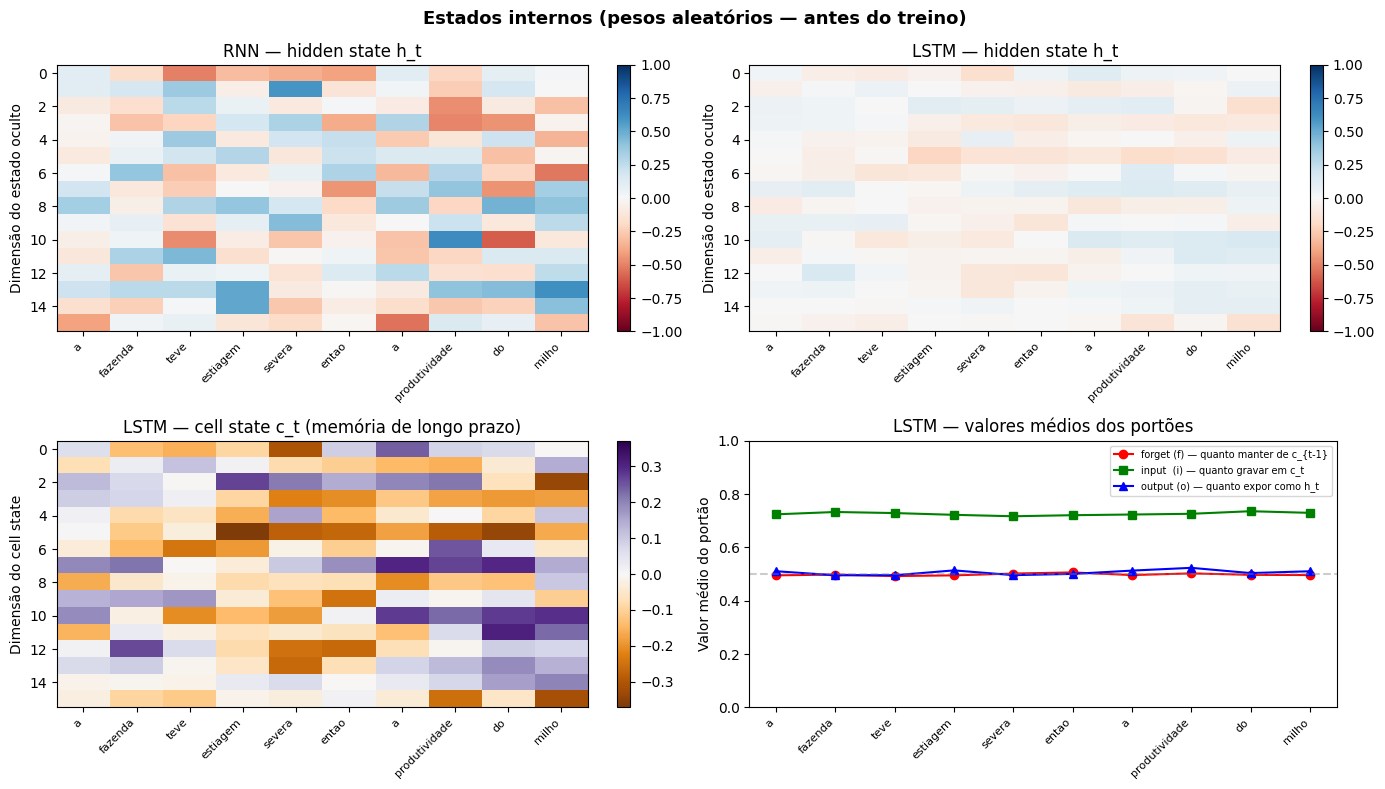

In [6]:
def plotar_estados(tokens, estados_rnn, hidden_lstm, cell_lstm, gates_lstm, titulo=""):
    """
    Plota 4 painéis:
      1. Estados ocultos da RNN ao longo da frase
      2. Hidden state da LSTM
      3. Cell state da LSTM (memória de longo prazo)
      4. Valores médios dos portões da LSTM (f, i, o)
    """
    T = len(tokens)
    mostrar_dims = min(16, estados_rnn.shape[1])  # mostra as primeiras 16 dims

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    if titulo:
        fig.suptitle(titulo, fontsize=13, fontweight="bold")

    rotulos_x = tokens

    # ── painel 1: RNN hidden state ─────────────────────────────────────────
    ax = axes[0, 0]
    im = ax.imshow(estados_rnn[:, :mostrar_dims].T,
                   aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
    ax.set_xticks(range(T))
    ax.set_xticklabels(rotulos_x, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Dimensão do estado oculto")
    ax.set_title("RNN — hidden state h_t")
    plt.colorbar(im, ax=ax, fraction=0.046)

    # ── painel 2: LSTM hidden state ────────────────────────────────────────
    ax = axes[0, 1]
    im = ax.imshow(hidden_lstm[:, :mostrar_dims].T,
                   aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
    ax.set_xticks(range(T))
    ax.set_xticklabels(rotulos_x, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Dimensão do estado oculto")
    ax.set_title("LSTM — hidden state h_t")
    plt.colorbar(im, ax=ax, fraction=0.046)

    # ── painel 3: LSTM cell state ──────────────────────────────────────────
    ax = axes[1, 0]
    # Cell state não é comprimido por tanh na saída, pode ter valores maiores
    vmax = np.abs(cell_lstm[:, :mostrar_dims]).max() or 1
    im = ax.imshow(cell_lstm[:, :mostrar_dims].T,
                   aspect="auto", cmap="PuOr", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(T))
    ax.set_xticklabels(rotulos_x, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Dimensão do cell state")
    ax.set_title("LSTM — cell state c_t (memória de longo prazo)")
    plt.colorbar(im, ax=ax, fraction=0.046)

    # ── painel 4: médias dos portões ───────────────────────────────────────
    ax = axes[1, 1]
    f_mean = gates_lstm["f"].mean(axis=1)  # média sobre dims a cada step
    i_mean = gates_lstm["i"].mean(axis=1)
    o_mean = gates_lstm["o"].mean(axis=1)

    ax.plot(range(T), f_mean, "r-o", label="forget (f) — quanto manter de c_{t-1}")
    ax.plot(range(T), i_mean, "g-s", label="input  (i) — quanto gravar em c_t")
    ax.plot(range(T), o_mean, "b-^", label="output (o) — quanto expor como h_t")
    ax.set_xticks(range(T))
    ax.set_xticklabels(rotulos_x, rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Valor médio do portão")
    ax.set_title("LSTM — valores médios dos portões")
    ax.legend(fontsize=7)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()


plotar_estados(
    tokens_teste,
    estados_rnn=estados,
    hidden_lstm=hs,
    cell_lstm=cs,
    gates_lstm=gates,
    titulo="Estados internos (pesos aleatórios — antes do treino)"
)

---
## Parte 7 — Treinamento Real com PyTorch

Agora vamos **treinar** modelos RNN e LSTM de verdade usando PyTorch.

### A tarefa: previsão de próxima palavra

Para cada token da sequência, o modelo deve prever o próximo token.  
O erro é medido pela **cross-entropy loss** entre a previsão e o token real.

### Detalhes do treino

- **Arquitetura:** embedding + RNN/LSTM + projeção linear
- **Embedding:** em vez de one-hot (esparso), usamos vetores densos aprendidos
- **Otimizador:** Adam (adaptativo, mais robusto que SGD puro para RNNs)
- **Gradient clipping:** limita a norma do gradiente para evitar explosão

In [7]:
# ── Preparação dos dados para PyTorch ──────────────────────────────────────

def frase_para_tensores(tokens, palavra2idx):
    """
    Converte uma lista de tokens em par (input, target) como tensores.

    Input:  tokens[0:-1]  (todos menos o último)
    Target: tokens[1:]    (todos menos o primeiro)

    Isso implementa a tarefa de prever o próximo token:
      dado tokens[t], prever tokens[t+1]

    Returns:
        x (LongTensor): índices dos tokens de entrada, shape (T-1,)
        y (LongTensor): índices dos tokens alvo,     shape (T-1,)
    """
    idx_unk = palavra2idx["<UNK>"]
    indices = [palavra2idx.get(t, idx_unk) for t in tokens]

    x = torch.tensor(indices[:-1], dtype=torch.long)
    y = torch.tensor(indices[1:],  dtype=torch.long)
    return x, y


# Cria todos os pares (x, y) do corpus
dados = [frase_para_tensores(tokens, palavra2idx) for tokens in corpus_tokenizado]

print(f"Pares de treinamento: {len(dados)}")
x0, y0 = dados[0]
print(f"Exemplo — frase 0:")
print(f"  Tokens: {corpus_tokenizado[0]}")
print(f"  x (input) : {x0.tolist()}")
print(f"  y (target): {y0.tolist()}")
print(f"  Tradução x: {[idx2palavra[i] for i in x0.tolist()]}")
print(f"  Tradução y: {[idx2palavra[i] for i in y0.tolist()]}")

Pares de treinamento: 20
Exemplo — frase 0:
  Tokens: ['a', 'fazenda', 'teve', 'estiagem', 'severa', 'entao', 'a', 'produtividade', 'do', 'milho', 'caiu']
  x (input) : [2, 24, 60, 23, 55, 22, 2, 46, 18, 33]
  y (target): [24, 60, 23, 55, 22, 2, 46, 18, 33, 9]
  Tradução x: ['a', 'fazenda', 'teve', 'estiagem', 'severa', 'entao', 'a', 'produtividade', 'do', 'milho']
  Tradução y: ['fazenda', 'teve', 'estiagem', 'severa', 'entao', 'a', 'produtividade', 'do', 'milho', 'caiu']


In [8]:
# ── Modelo de Linguagem Genérico com RNN ou LSTM ───────────────────────────

class ModeloLinguagem(nn.Module):
    """
    Modelo de linguagem com embedding + RNN ou LSTM + projeção.

    Arquitetura:
        token_idx → Embedding → RNN/LSTM → Linear → logits

    Parâmetros:
        vocab_size (int): Tamanho do vocabulário.
        embed_dim  (int): Dimensão dos embeddings.
        hidden_dim (int): Dimensão do estado oculto.
        tipo       (str): 'rnn' ou 'lstm'.
        n_camadas  (int): Número de camadas empilhadas.
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim, tipo="rnn", n_camadas=1):
        super().__init__()

        self.tipo = tipo
        self.hidden_dim = hidden_dim
        self.n_camadas = n_camadas

        # Embedding: converte índice inteiro em vetor denso aprendido
        # Vantagem sobre one-hot: dimensionalidade menor, distâncias semânticas
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Célula recorrente: PyTorch usa a mesma interface para RNN e LSTM
        if tipo == "rnn":
            # nn.RNN implementa: h_t = tanh(W_ih * x_t + W_hh * h_{t-1} + b)
            self.recorrente = nn.RNN(
                input_size=embed_dim,
                hidden_size=hidden_dim,
                num_layers=n_camadas,
                batch_first=True,   # input shape: (batch, seq, features)
                dropout=0.0,
            )
        elif tipo == "lstm":
            # nn.LSTM implementa os 4 portões reais
            self.recorrente = nn.LSTM(
                input_size=embed_dim,
                hidden_size=hidden_dim,
                num_layers=n_camadas,
                batch_first=True,
                dropout=0.0,
            )
        else:
            raise ValueError(f"tipo deve ser 'rnn' ou 'lstm', recebeu '{tipo}'")

        # Projeção final: estado oculto → logits do vocabulário
        self.projecao = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, estado_inicial=None):
        """
        Forward pass.

        Args:
            x (LongTensor): Índices dos tokens, shape (batch, seq_len).
            estado_inicial: Estado oculto inicial (None = zeros).

        Returns:
            logits (Tensor): shape (batch, seq_len, vocab_size).
            estado_final: Estado oculto após processar a sequência.
        """
        # x: (batch, seq) → embeds: (batch, seq, embed_dim)
        embeds = self.embedding(x)

        # Passa pela célula recorrente
        # saida: (batch, seq, hidden_dim)
        saida, estado_final = self.recorrente(embeds, estado_inicial)

        # Projeta cada passo para logits do vocabulário
        logits = self.projecao(saida)  # (batch, seq, vocab_size)

        return logits, estado_final

    def contar_parametros(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Hiperparâmetros
EMBED_DIM  = 32
HIDDEN_DIM = 64

modelo_rnn  = ModeloLinguagem(V, EMBED_DIM, HIDDEN_DIM, tipo="rnn")
modelo_lstm = ModeloLinguagem(V, EMBED_DIM, HIDDEN_DIM, tipo="lstm")

print(f"Parâmetros — RNN : {modelo_rnn.contar_parametros():,}")
print(f"Parâmetros — LSTM: {modelo_lstm.contar_parametros():,}")
print()
print("A LSTM tem ~4x mais parâmetros que a RNN equivalente")
print("porque precisa de 4 matrizes (uma por portão) onde a RNN usa 1.")

Parâmetros — RNN : 12,383
Parâmetros — LSTM: 31,199

A LSTM tem ~4x mais parâmetros que a RNN equivalente
porque precisa de 4 matrizes (uma por portão) onde a RNN usa 1.


In [9]:
def treinar(modelo, dados, n_epocas=300, lr=0.01, clip_grad=1.0, verbose=True):
    """
    Loop de treinamento por máxima verossimilhança (cross-entropy).

    A cada época:
      1. Percorre todas as frases do corpus (SGD por frase)
      2. Calcula a loss (cross-entropy entre previsão e próximo token real)
      3. Backpropagation — calcula gradientes
      4. Gradient clipping — limita a norma para evitar explosão
      5. Passo do otimizador — atualiza os pesos

    Args:
        modelo: O modelo PyTorch.
        dados: Lista de pares (x, y) já como tensores.
        n_epocas (int): Número de épocas de treino.
        lr (float): Learning rate.
        clip_grad (float): Norma máxima do gradiente.
        verbose (bool): Imprimir progresso.

    Returns:
        list[float]: Histórico de loss por época.
    """
    otimizador = optim.Adam(modelo.parameters(), lr=lr)
    criterio   = nn.CrossEntropyLoss(ignore_index=0)  # ignora <PAD>

    historico = []

    for epoca in range(1, n_epocas + 1):
        modelo.train()
        loss_total = 0.0

        # Embaralha as frases a cada época (evita overfitting de ordem)
        indices = list(range(len(dados)))
        random.shuffle(indices)

        for idx in indices:
            x, y = dados[idx]

            # Adiciona dimensão de batch (o modelo espera batch_first)
            # x: (seq,) → (1, seq)
            x = x.unsqueeze(0)
            y = y.unsqueeze(0)

            otimizador.zero_grad()

            # Forward
            logits, _ = modelo(x)
            # logits: (1, seq, vocab) → (seq, vocab) para a loss
            logits = logits.squeeze(0)
            y      = y.squeeze(0)

            loss = criterio(logits, y)

            # Backward
            loss.backward()

            # Gradient clipping: evita explosão de gradiente
            # (especialmente importante para RNN)
            nn.utils.clip_grad_norm_(modelo.parameters(), clip_grad)

            otimizador.step()
            loss_total += loss.item()

        loss_media = loss_total / len(dados)
        historico.append(loss_media)

        if verbose and (epoca % 50 == 0 or epoca == 1):
            perplexidade = np.exp(loss_media)
            print(f"Época {epoca:>4}/{n_epocas} | Loss: {loss_media:.4f} | Perplexidade: {perplexidade:.1f}")

    return historico


print("Treinando RNN...")
hist_rnn = treinar(modelo_rnn, dados, n_epocas=300, lr=0.01)

print()
print("Treinando LSTM...")
hist_lstm = treinar(modelo_lstm, dados, n_epocas=300, lr=0.01)

Treinando RNN...
Época    1/300 | Loss: 3.2357 | Perplexidade: 25.4
Época   50/300 | Loss: 0.3175 | Perplexidade: 1.4
Época  100/300 | Loss: 0.1982 | Perplexidade: 1.2
Época  150/300 | Loss: 0.2486 | Perplexidade: 1.3
Época  200/300 | Loss: 0.2913 | Perplexidade: 1.3
Época  250/300 | Loss: 0.2522 | Perplexidade: 1.3
Época  300/300 | Loss: 0.2073 | Perplexidade: 1.2

Treinando LSTM...
Época    1/300 | Loss: 3.7564 | Perplexidade: 42.8
Época   50/300 | Loss: 0.1709 | Perplexidade: 1.2
Época  100/300 | Loss: 0.1658 | Perplexidade: 1.2
Época  150/300 | Loss: 0.1657 | Perplexidade: 1.2
Época  200/300 | Loss: 0.1628 | Perplexidade: 1.2
Época  250/300 | Loss: 0.1607 | Perplexidade: 1.2
Época  300/300 | Loss: 0.1613 | Perplexidade: 1.2


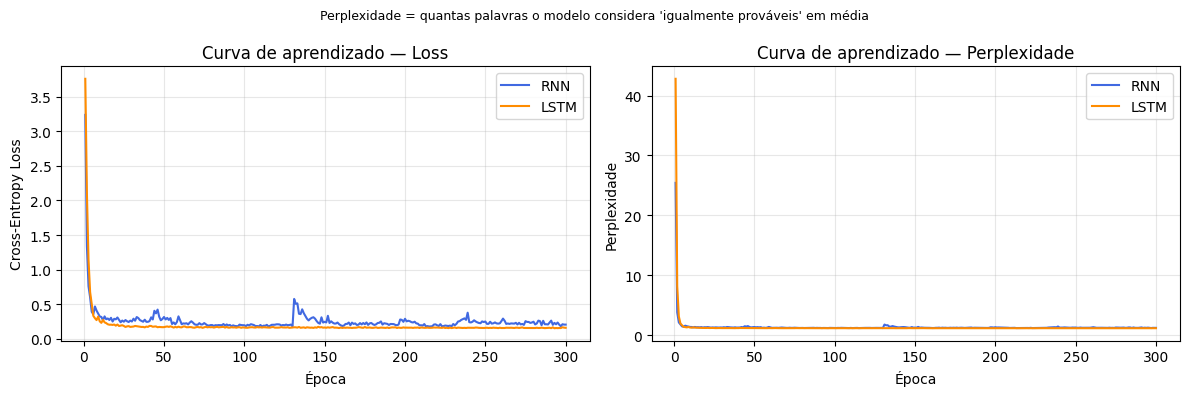

Loss final — RNN : 0.2073  (perplexidade: 1.2)
Loss final — LSTM: 0.1613  (perplexidade: 1.2)


In [10]:
# ── Curvas de aprendizado ──────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epocas = range(1, len(hist_rnn) + 1)

# Loss
ax1.plot(epocas, hist_rnn,  label="RNN",  color="royalblue")
ax1.plot(epocas, hist_lstm, label="LSTM", color="darkorange")
ax1.set_xlabel("Época")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_title("Curva de aprendizado — Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Perplexidade
ax2.plot(epocas, np.exp(hist_rnn),  label="RNN",  color="royalblue")
ax2.plot(epocas, np.exp(hist_lstm), label="LSTM", color="darkorange")
ax2.set_xlabel("Época")
ax2.set_ylabel("Perplexidade")
ax2.set_title("Curva de aprendizado — Perplexidade")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Perplexidade = quantas palavras o modelo considera 'igualmente prováveis' em média",
             fontsize=9)
plt.tight_layout()
plt.show()

print(f"Loss final — RNN : {hist_rnn[-1]:.4f}  (perplexidade: {np.exp(hist_rnn[-1]):.1f})")
print(f"Loss final — LSTM: {hist_lstm[-1]:.4f}  (perplexidade: {np.exp(hist_lstm[-1]):.1f})")

---
## Parte 8 — Teste: As Redes Capturam a Dependência Longa?

Esta é a pergunta central do Demo 2:

> Dado o contexto `"a fazenda teve estiagem severa entao a produtividade do milho"`,  
> o modelo prevê `"caiu"`?  
> E dado `"a fazenda teve chuva regular entao a produtividade do milho"`,  
> o modelo prevê `"subiu"`?

A palavra-chave (`estiagem` / `chuva`) está **7 tokens antes** do ponto de previsão.

In [11]:
def prever_pytorch(modelo, tokens, palavra2idx, idx2palavra, top_k=5):
    """
    Prevê as top_k próximas palavras usando um modelo PyTorch treinado.

    Args:
        modelo: ModeloLinguagem (PyTorch).
        tokens (list[str]): Contexto de entrada.
        palavra2idx (dict): Mapa palavra → índice.
        idx2palavra (dict): Mapa índice → palavra.
        top_k (int): Quantas previsões retornar.

    Returns:
        list[tuple]: [(palavra, probabilidade), ...]
    """
    modelo.eval()
    with torch.no_grad():
        idx_unk = palavra2idx["<UNK>"]
        x = torch.tensor(
            [palavra2idx.get(t, idx_unk) for t in tokens],
            dtype=torch.long
        ).unsqueeze(0)  # (1, seq)

        logits, _ = modelo(x)
        logit_ultimo = logits[0, -1, :]          # logits do último passo
        probs = F.softmax(logit_ultimo, dim=-1)  # normaliza para probabilidades

    top = torch.argsort(probs, descending=True)[:top_k]
    return [(idx2palavra[i.item()], probs[i].item()) for i in top]


# ── Contextos de teste ─────────────────────────────────────────────────────
ctx_estiagem = tokenizar("a fazenda teve estiagem severa entao a produtividade do milho")
ctx_chuva    = tokenizar("a fazenda teve chuva regular entao a produtividade do milho")
ctx_apenas_milho = ["milho"]  # sem nenhum contexto causal


def mostrar_comparacao(ctx, modelos_dict, top_k=6):
    print(f"Contexto: {' '.join(ctx)}")
    print(f"         {'─' * 50}")
    print(f"  {'Palavra':<18}", end="")
    for nome in modelos_dict:
        print(f"  {nome:>12}", end="")
    print()
    print("  " + "─" * (18 + 14 * len(modelos_dict)))

    # Coleta previsões de todos os modelos
    resultados = {}
    for nome, modelo_fn in modelos_dict.items():
        preds = modelo_fn(ctx)
        resultados[nome] = {p: prob for p, prob in preds}

    # Palavras únicas no top-k de qualquer modelo
    todas_palavras = set()
    for nome, modelo_fn in modelos_dict.items():
        for p, _ in modelo_fn(ctx)[:top_k]:
            todas_palavras.add(p)

    # Ordena pela média de probabilidade
    medias = {p: np.mean([resultados[n].get(p, 0) for n in modelos_dict])
              for p in todas_palavras}
    palavras_ordenadas = sorted(medias, key=lambda p: -medias[p])[:top_k]

    for palavra in palavras_ordenadas:
        marcador = "→" if palavra in ("caiu", "subiu") else " "
        print(f" {marcador} {palavra:<18}", end="")
        for nome in modelos_dict:
            prob = resultados[nome].get(palavra, 0)
            barra = "█" * int(prob * 40)
            print(f"  {prob:>5.1%} {barra:<6}", end="")
        print()
    print()


# Funções de previsão encapsuladas para cada modelo
modelos_comparacao = {
    "RNN":  lambda ctx: prever_pytorch(modelo_rnn,  ctx, palavra2idx, idx2palavra),
    "LSTM": lambda ctx: prever_pytorch(modelo_lstm, ctx, palavra2idx, idx2palavra),
}

print("=" * 70)
print("RESULTADO DO TESTE — dependência longa")
print("=" * 70)
print()
print("→ = palavra esperada dado o contexto")
print()

mostrar_comparacao(ctx_estiagem,    modelos_comparacao)
mostrar_comparacao(ctx_chuva,       modelos_comparacao)
mostrar_comparacao(ctx_apenas_milho, modelos_comparacao)

RESULTADO DO TESTE — dependência longa

→ = palavra esperada dado o contexto

Contexto: a fazenda teve estiagem severa entao a produtividade do milho
         ──────────────────────────────────────────────────
  Palavra                      RNN          LSTM
  ──────────────────────────────────────────────
 → caiu                99.9% ███████████████████████████████████████  100.0% ███████████████████████████████████████
 → subiu                0.0%          0.0%       
   depende              0.0%          0.0%       
   produtividade        0.0%          0.0%       
   estiagem             0.0%          0.0%       
   seca                 0.0%          0.0%       

Contexto: a fazenda teve chuva regular entao a produtividade do milho
         ──────────────────────────────────────────────────
  Palavra                      RNN          LSTM
  ──────────────────────────────────────────────
 → subiu               99.9% ███████████████████████████████████████  100.0% ███████████████████

---
## Parte 9 — Visualizando os Estados Internos Pós-Treino

Vamos rodar o forward pass manual (NumPy) nas redes treinadas pelo PyTorch.

Para isso, copiamos os pesos aprendidos pelo PyTorch para nossas implementações NumPy — e observamos como os estados internos evoluem na frase com a causa `"estiagem"`.

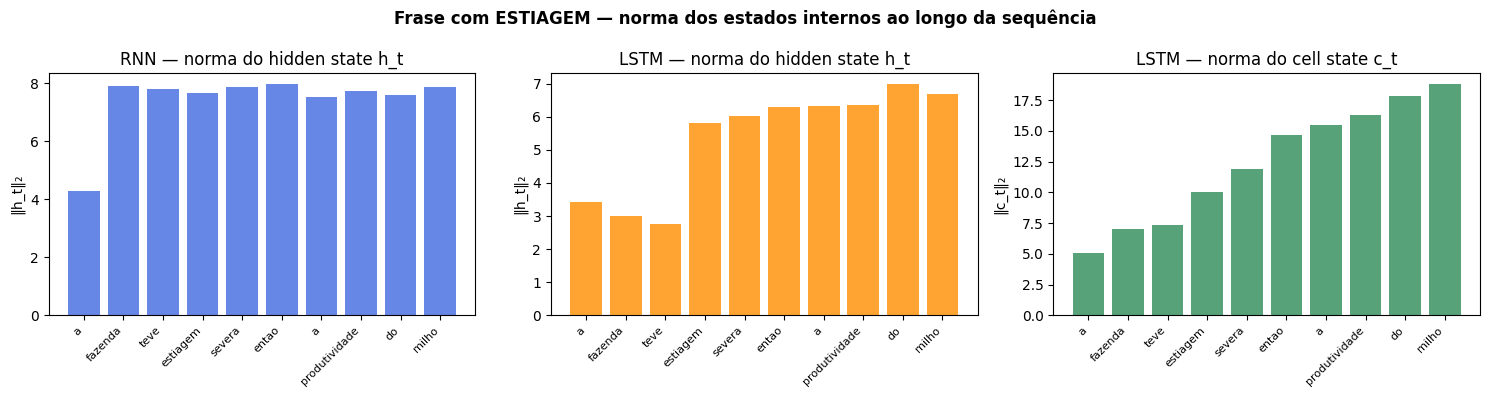

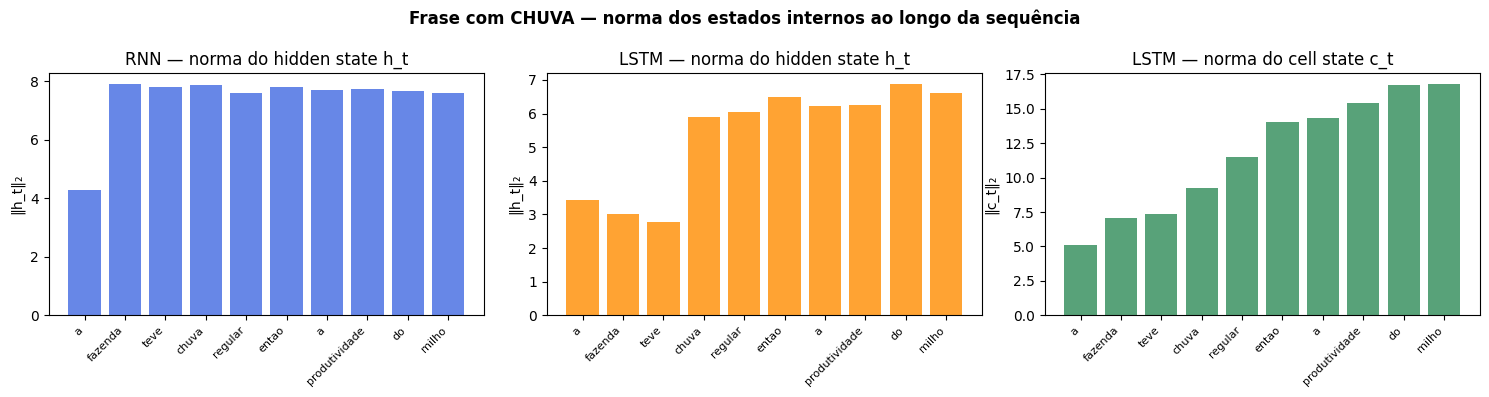

In [12]:
def extrair_estados_rnn_pytorch(modelo_pt, tokens, palavra2idx):
    """
    Extrai os estados ocultos passo a passo de um modelo PyTorch RNN/LSTM,
    passando os tokens um a um para capturar o estado em cada posição.

    Returns:
        hidden_np (np.ndarray): Shape (T, H) — estado h_t a cada token.
        cell_np   (np.ndarray ou None): Shape (T, H) — cell state (só LSTM).
    """
    modelo_pt.eval()
    idx_unk = palavra2idx["<UNK>"]
    indices = [palavra2idx.get(t, idx_unk) for t in tokens]

    estados_h = []
    estados_c = []
    estado = None

    with torch.no_grad():
        for idx in indices:
            x = torch.tensor([[idx]], dtype=torch.long)  # (1, 1)
            _, estado = modelo_pt.recorrente(
                modelo_pt.embedding(x),  # (1, 1, embed)
                estado
            )

            if modelo_pt.tipo == "lstm":
                h, c = estado
                estados_h.append(h[0, 0].numpy())   # (H,)
                estados_c.append(c[0, 0].numpy())
            else:
                estados_h.append(estado[0, 0].numpy())

    hidden_np = np.array(estados_h)   # (T, H)
    cell_np   = np.array(estados_c) if estados_c else None

    return hidden_np, cell_np


def plotar_norma_estados(tokens, h_rnn, h_lstm, c_lstm, titulo=""):
    """
    Plota a norma L2 do estado oculto ao longo da frase.
    Mudanças grandes na norma indicam que aquele token causou impacto no estado.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    if titulo:
        fig.suptitle(titulo, fontsize=12, fontweight="bold")

    T = len(tokens)
    xs = range(T)

    # Norma do hidden state RNN
    norma_rnn = np.linalg.norm(h_rnn, axis=1)
    axes[0].bar(xs, norma_rnn, color="royalblue", alpha=0.8)
    axes[0].set_xticks(xs)
    axes[0].set_xticklabels(tokens, rotation=45, ha="right", fontsize=8)
    axes[0].set_title("RNN — norma do hidden state h_t")
    axes[0].set_ylabel("‖h_t‖₂")

    # Norma do hidden state LSTM
    norma_hlstm = np.linalg.norm(h_lstm, axis=1)
    axes[1].bar(xs, norma_hlstm, color="darkorange", alpha=0.8)
    axes[1].set_xticks(xs)
    axes[1].set_xticklabels(tokens, rotation=45, ha="right", fontsize=8)
    axes[1].set_title("LSTM — norma do hidden state h_t")
    axes[1].set_ylabel("‖h_t‖₂")

    # Norma do cell state LSTM (memória de longo prazo)
    if c_lstm is not None:
        norma_clstm = np.linalg.norm(c_lstm, axis=1)
        axes[2].bar(xs, norma_clstm, color="seagreen", alpha=0.8)
        axes[2].set_xticks(xs)
        axes[2].set_xticklabels(tokens, rotation=45, ha="right", fontsize=8)
        axes[2].set_title("LSTM — norma do cell state c_t")
        axes[2].set_ylabel("‖c_t‖₂")

    plt.tight_layout()
    plt.show()


# Extrai estados para a frase com estiagem
h_rnn_estiagem,  _               = extrair_estados_rnn_pytorch(modelo_rnn,  ctx_estiagem, palavra2idx)
h_lstm_estiagem, c_lstm_estiagem = extrair_estados_rnn_pytorch(modelo_lstm, ctx_estiagem, palavra2idx)

h_rnn_chuva,  _             = extrair_estados_rnn_pytorch(modelo_rnn,  ctx_chuva, palavra2idx)
h_lstm_chuva, c_lstm_chuva  = extrair_estados_rnn_pytorch(modelo_lstm, ctx_chuva, palavra2idx)

plotar_norma_estados(
    ctx_estiagem,
    h_rnn_estiagem, h_lstm_estiagem, c_lstm_estiagem,
    titulo="Frase com ESTIAGEM — norma dos estados internos ao longo da sequência"
)

plotar_norma_estados(
    ctx_chuva,
    h_rnn_chuva, h_lstm_chuva, c_lstm_chuva,
    titulo="Frase com CHUVA — norma dos estados internos ao longo da sequência"
)

DIVERGÊNCIA ENTRE CONTEXTOS — RNN


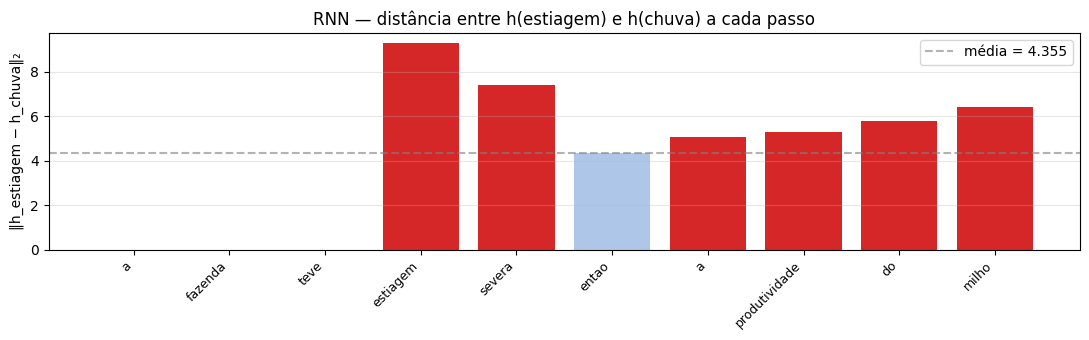

Distância a cada passo:
  a                  0.0000  
  fazenda            0.0000  
  teve               0.0000  
  estiagem           9.2736  ██████████████████████████████
  severa             7.3976  ███████████████████████
  entao              4.3197  █████████████
  a                  5.0742  ████████████████
  produtividade      5.3040  █████████████████
  do                 5.7622  ██████████████████
  milho              6.4138  ████████████████████

DIVERGÊNCIA ENTRE CONTEXTOS — LSTM


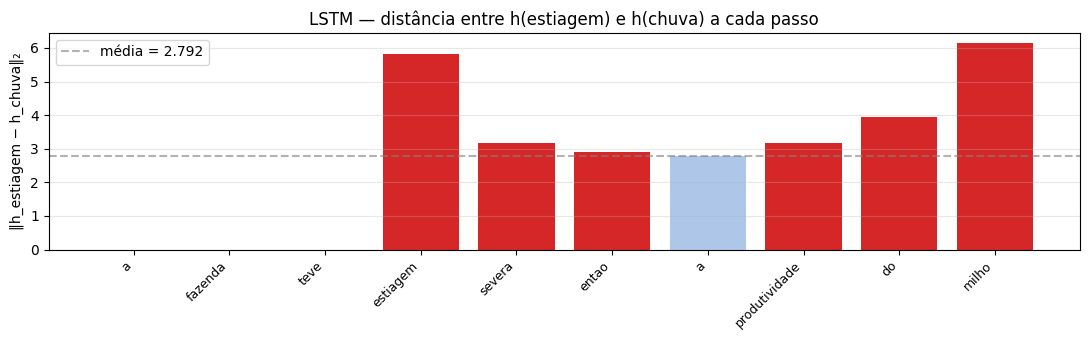

Distância a cada passo:
  a                  0.0000  
  fazenda            0.0000  
  teve               0.0000  
  estiagem           5.8122  ████████████████████████████
  severa             3.1604  ███████████████
  entao              2.9155  ██████████████
  a                  2.7887  █████████████
  produtividade      3.1652  ███████████████
  do                 3.9405  ███████████████████
  milho              6.1413  ██████████████████████████████

Interpretação: se a distância cai perto de zero nos tokens intermediários,
o modelo não consegue mais distinguir os dois contextos — e vai errar a previsão.


In [13]:
# ── Divergência entre os dois contextos ───────────────────────────────────
#
# Se o modelo aprendeu a dependência longa, os estados internos após
# 'estiagem' e após 'chuva' devem ser diferentes — e essa diferença
# deve PERSISTIR ao longo de toda a frase até o ponto de previsão.
#
# Se o modelo esquece, os estados convergem no meio do caminho.

def plotar_divergencia(tokens_a, tokens_b, h_a, h_b, label_a, label_b, titulo=""):
    """
    Plota a distância euclidiana entre os estados internos dos dois contextos
    a cada posição. Se a distância cai para perto de zero, os contextos
    se tornaram indistinguíveis para o modelo.
    """
    # Usa o menor comprimento (as frases têm o mesmo tamanho aqui)
    T = min(len(tokens_a), len(tokens_b), len(h_a), len(h_b))
    tokens = tokens_a[:T]

    distancias = np.linalg.norm(h_a[:T] - h_b[:T], axis=1)

    fig, ax = plt.subplots(figsize=(11, 3.5))
    bars = ax.bar(range(T), distancias, color=[
        "#d62728" if d > distancias.mean() else "#aec7e8"
        for d in distancias
    ])
    ax.set_xticks(range(T))
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("‖h_estiagem − h_chuva‖₂")
    ax.axhline(distancias.mean(), color="gray", linestyle="--", alpha=0.6,
               label=f"média = {distancias.mean():.3f}")
    ax.set_title(titulo)
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("Distância a cada passo:")
    for token, d in zip(tokens, distancias):
        barra = "█" * int(d / distancias.max() * 30)
        print(f"  {token:<18} {d:.4f}  {barra}")
    print()


print("=" * 65)
print("DIVERGÊNCIA ENTRE CONTEXTOS — RNN")
print("=" * 65)
plotar_divergencia(
    ctx_estiagem, ctx_chuva,
    h_rnn_estiagem, h_rnn_chuva,
    "estiagem", "chuva",
    titulo="RNN — distância entre h(estiagem) e h(chuva) a cada passo"
)

print("=" * 65)
print("DIVERGÊNCIA ENTRE CONTEXTOS — LSTM")
print("=" * 65)
plotar_divergencia(
    ctx_estiagem, ctx_chuva,
    h_lstm_estiagem, h_lstm_chuva,
    "estiagem", "chuva",
    titulo="LSTM — distância entre h(estiagem) e h(chuva) a cada passo"
)

print("Interpretação: se a distância cai perto de zero nos tokens intermediários,")
print("o modelo não consegue mais distinguir os dois contextos — e vai errar a previsão.")

---
## Parte 10 — Comparação Final: N-Grama vs RNN vs LSTM

Juntamos os três modelos para a mesma pergunta, lado a lado.

In [14]:
from collections import defaultdict

# Treina bigrama no mesmo corpus para comparação
def construir_bigrama(corpus_raw):
    modelo = defaultdict(list)
    for frase in corpus_raw:
        tokens = tokenizar(frase)
        for a, b in zip(tokens, tokens[1:]):
            modelo[a].append(b)
    return modelo

def prever_bigrama(modelo_bg, tokens, top_k=5):
    ultima = tokens[-1]
    if ultima not in modelo_bg:
        return []
    candidatos = Counter(modelo_bg[ultima])
    total = sum(candidatos.values())
    return [(p, n/total) for p, n in candidatos.most_common(top_k)]


modelo_bg = construir_bigrama(corpus_raw)

def imprimir_previsoes(contexto, label):
    print(f"\n── {label} ──")
    print(f"   Contexto: ...{' '.join(contexto[-4:])}")
    print()

    print(f"   {'Modelo':<12} {'caiu':>8} {'subiu':>8} {'vencedor'}")
    print(f"   {'─'*40}")

    # Bigrama
    bg = dict(prever_bigrama(modelo_bg, contexto))
    p_caiu_bg  = bg.get("caiu",  0)
    p_subiu_bg = bg.get("subiu", 0)
    venc_bg = "caiu" if p_caiu_bg > p_subiu_bg else ("subiu" if p_subiu_bg > p_caiu_bg else "empate")
    print(f"   {'Bigrama':<12} {p_caiu_bg:>7.1%} {p_subiu_bg:>8.1%}  {venc_bg}")

    # RNN
    rnn_preds = dict(prever_pytorch(modelo_rnn, contexto, palavra2idx, idx2palavra))
    p_caiu_rnn  = rnn_preds.get("caiu",  0)
    p_subiu_rnn = rnn_preds.get("subiu", 0)
    venc_rnn = "caiu" if p_caiu_rnn > p_subiu_rnn else ("subiu" if p_subiu_rnn > p_caiu_rnn else "empate")
    print(f"   {'RNN':<12} {p_caiu_rnn:>7.1%} {p_subiu_rnn:>8.1%}  {venc_rnn}")

    # LSTM
    lstm_preds = dict(prever_pytorch(modelo_lstm, contexto, palavra2idx, idx2palavra))
    p_caiu_lstm  = lstm_preds.get("caiu",  0)
    p_subiu_lstm = lstm_preds.get("subiu", 0)
    venc_lstm = "caiu" if p_caiu_lstm > p_subiu_lstm else ("subiu" if p_subiu_lstm > p_caiu_lstm else "empate")
    print(f"   {'LSTM':<12} {p_caiu_lstm:>7.1%} {p_subiu_lstm:>8.1%}  {venc_lstm}")

    # Resposta correta
    correta = "caiu" if "estiagem" in contexto else "subiu"
    print(f"   {'─'*40}")
    print(f"   Resposta correta: {correta}")


print("=" * 50)
print("COMPARAÇÃO FINAL — Bigrama vs RNN vs LSTM")
print("=" * 50)
imprimir_previsoes(ctx_estiagem, "CONTEXTO: estiagem (esperado: caiu)")
imprimir_previsoes(ctx_chuva,    "CONTEXTO: chuva    (esperado: subiu)")

COMPARAÇÃO FINAL — Bigrama vs RNN vs LSTM

── CONTEXTO: estiagem (esperado: caiu) ──
   Contexto: ...a produtividade do milho

   Modelo           caiu    subiu vencedor
   ────────────────────────────────────────
   Bigrama        42.9%    42.9%  empate
   RNN            99.9%     0.0%  caiu
   LSTM          100.0%     0.0%  caiu
   ────────────────────────────────────────
   Resposta correta: caiu

── CONTEXTO: chuva    (esperado: subiu) ──
   Contexto: ...a produtividade do milho

   Modelo           caiu    subiu vencedor
   ────────────────────────────────────────
   Bigrama        42.9%    42.9%  empate
   RNN             0.0%    99.9%  subiu
   LSTM            0.0%   100.0%  subiu
   ────────────────────────────────────────
   Resposta correta: subiu


---
## Parte 11 — Conclusão

### O que vimos neste notebook

| Modelo | Memória | Treino | Dependência longa |
|---|---|---|---|
| **Bigrama** | Última palavra | Contagem | Não — cego para o contexto |
| **RNN** | Estado oculto comprimido | Backprop + BPTT | Parcial — gradiente desvanece |
| **LSTM** | Cell state + portões | Backprop + BPTT | Melhor — mas ainda limitado |

---

### O que a LSTM resolve

- **Portão de esquecimento** (`f_t`): o modelo aprende *o que* descartar da memória
- **Portão de entrada** (`i_t`): o modelo aprende *o que* gravar quando encontra algo importante
- **Cell state** (`c_t`): flui com modificações mínimas — o gradiente não desvanece tanto

Com isso, palavras importantes como `"estiagem"` podem imprimir um sinal no `c_t` que persiste por vários passos.

### O que a LSTM não resolve

1. **É sequencial:** token por token — impossível paralelizar. Treino lento em frases longas.
2. **Gargalo de compressão:** toda a informação da frase precisa caber em um vetor `h_t` de tamanho fixo.
3. **Dependências muito longas:** em textos de centenas de tokens, mesmo a LSTM perde o fio.
4. **Direcionalidade:** a LSTM padrão lê da esquerda para a direita — não "vê o futuro".

---

### O salto do transformer

O transformer elimina a recorrência completamente.  
Em vez de passar informação token a token, cada token **olha diretamente para todos os outros** via atenção:

```
LSTM:        estiagem → ... → ... → ... → ... → ... → milho → [?]
             (informação viaja pelo gargalo do hidden state)

Transformer: estiagem ──────────────────────────────── milho
                  ↑ conexão direta, sem intermediários
```

Isso é o que veremos no **Demo 3**.

---

> **Frase para guardar:**  
> *"O transformer mudou o jogo porque trocou uma memória apertada e sequencial por um mecanismo de relação global entre tokens."*